# Logistic Regression from Scratch (Binary Classification)

## Dataset: Pima Indians Diabetes

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Load Dataset

In [ ]:

data = pd.read_csv(r"D:\SASTRA\2025 to 2026 AY\EVEN\MACHINE LEARNING LAB INT407\LAB EXPTS 2026\EXPT 4\diabetes.csv")
data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Preprocessing

In [ ]:

X = data.drop(columns=['Outcome']).values
y = data['Outcome'].values


## Train-Test Split

In [ ]:

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train = X[indices[:split]]
X_test  = X[indices[split:]]
y_train = y[indices[:split]]
y_test  = y[indices[split:]]


## Feature Scaling

In [ ]:

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std


## Logistic Regression from Scratch

In [ ]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss(y, y_hat):
    eps = 1e-9
    return -np.mean(y*np.log(y_hat+eps)+(1-y)*np.log(1-y_hat+eps))

def train(X, y, lr=0.05, epochs=4000):
    w = np.zeros(X.shape[1])
    b = 0
    losses = []

    for _ in range(epochs):
        y_hat = sigmoid(np.dot(X, w) + b)
        dw = np.dot(X.T, (y_hat - y)) / len(y)
        db = np.mean(y_hat - y)

        w -= lr * dw
        b -= lr * db
        losses.append(loss(y, y_hat))

    return w, b, losses


## Training

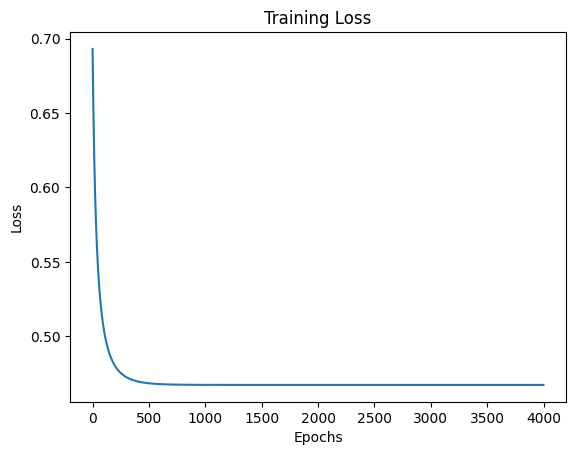

In [ ]:

weights, bias, losses = train(X_train, y_train)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


## Evaluation

In [ ]:

def predict(X, w, b):
    return (sigmoid(np.dot(X, w) + b) >= 0.5).astype(int)

y_pred = predict(X_test, weights, bias)
accuracy = np.mean(y_pred == y_test)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.7532467532467533


# Precision, Recall, F1-Score, ROC-AUC (From Scratch + sklearn metrics)

In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [ ]:

# Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Precision: 0.7380952380952381
Recall   : 0.5344827586206896
F1 Score : 0.62


In [ ]:

# ROC-AUC Score
y_probs = sigmoid(np.dot(X_test, weights) + bias)

roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.8360272988505748


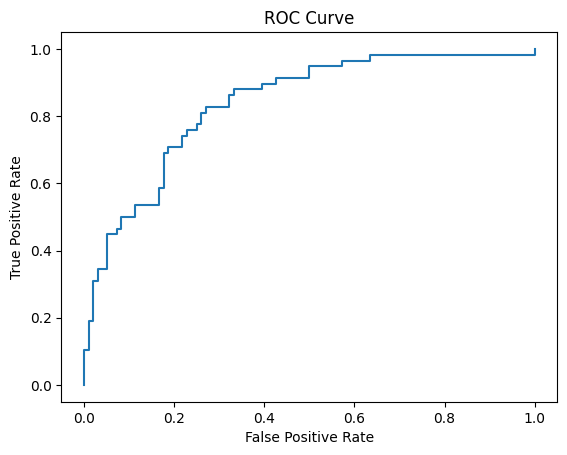

In [ ]:

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
